In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

In [2]:
vocab_size = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 26s 2us/step
Training data shape: (25000, 200)
Test data shape: (25000, 200)


In [3]:
rnn_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    SimpleRNN(32),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

C:\Users\athar\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.6940 - loss: 0.5616 - val_accuracy: 0.8244 - val_loss: 0.4031
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.8676 - loss: 0.3216 - val_accuracy: 0.8027 - val_loss: 0.4233
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 39s 99ms/step - accuracy: 0.8987 - loss: 0.2568 - val_accuracy: 0.8278 - val_loss: 0.4165
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 92ms/step - accuracy: 0.9435 - loss: 0.1538 - val_accuracy: 0.8213 - val_loss: 0.5000
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - accuracy: 0.9766 - loss: 0.0745 - val_accuracy: 0.8248 - val_loss: 0.5507


In [4]:
lstm_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 66s 160ms/step - accuracy: 0.8015 - loss: 0.4169 - val_accuracy: 0.8653 - val_loss: 0.3222
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 67s 170ms/step - accuracy: 0.9046 - loss: 0.2446 - val_accuracy: 0.8695 - val_loss: 0.3053
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 86s 179ms/step - accuracy: 0.9282 - loss: 0.1902 - val_accuracy: 0.8722 - val_loss: 0.3303
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 174ms/step - accuracy: 0.9472 - loss: 0.1455 - val_accuracy: 0.8649 - val_loss: 0.3910
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 73s 187ms/step - accuracy: 0.9552 - loss: 0.1222 - val_accuracy: 0.8621 - val_loss: 0.4159


In [5]:
gru_model = Sequential([
    Embedding(vocab_size, 32, input_length=max_length),
    GRU(32),
    Dense(1, activation='sigmoid')
])

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 203ms/step - accuracy: 0.7778 - loss: 0.4484 - val_accuracy: 0.8261 - val_loss: 0.3881
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 77s 198ms/step - accuracy: 0.8813 - loss: 0.2979 - val_accuracy: 0.8590 - val_loss: 0.3321
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 75s 192ms/step - accuracy: 0.9148 - loss: 0.2216 - val_accuracy: 0.8435 - val_loss: 0.3566
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 74s 189ms/step - accuracy: 0.9328 - loss: 0.1834 - val_accuracy: 0.8536 - val_loss: 0.3735
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 84s 214ms/step - accuracy: 0.9431 - loss: 0.1568 - val_accuracy: 0.8576 - val_loss: 0.3536


Graph for Individual Models

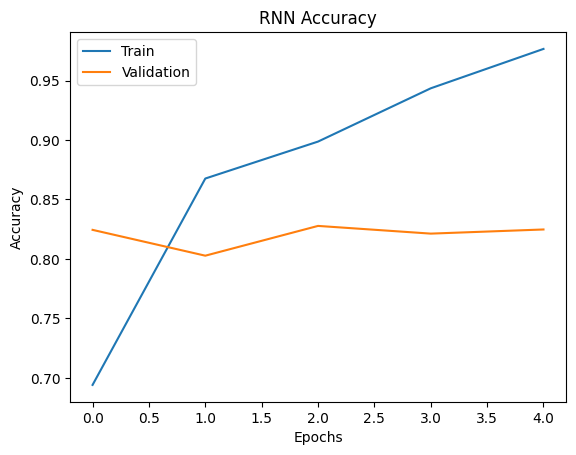

In [6]:
plt.plot(rnn_history.history['accuracy'])
plt.plot(rnn_history.history['val_accuracy'])
plt.title("RNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

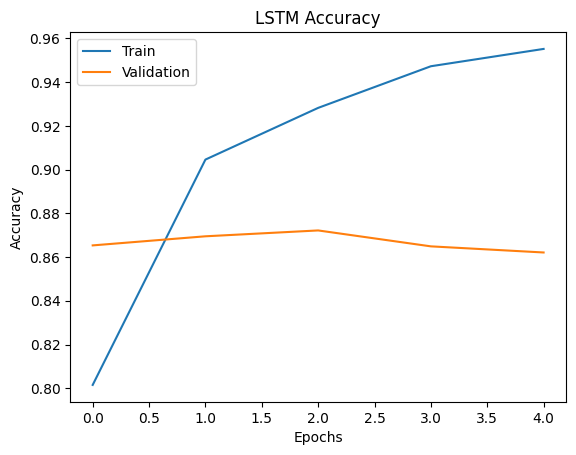

In [7]:
plt.plot(lstm_history.history['accuracy'])
plt.plot(lstm_history.history['val_accuracy'])
plt.title("LSTM Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

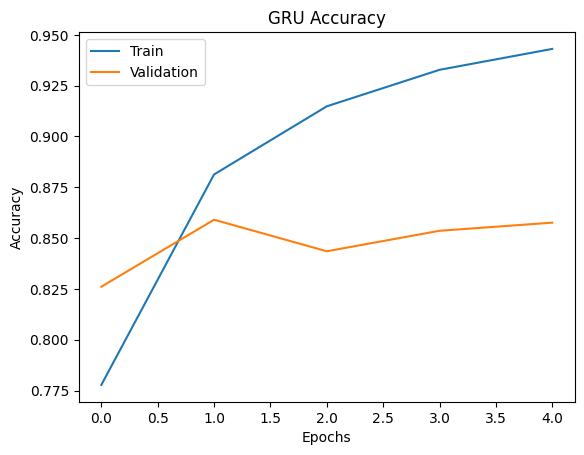

In [8]:
plt.plot(gru_history.history['accuracy'])
plt.plot(gru_history.history['val_accuracy'])
plt.title("GRU Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

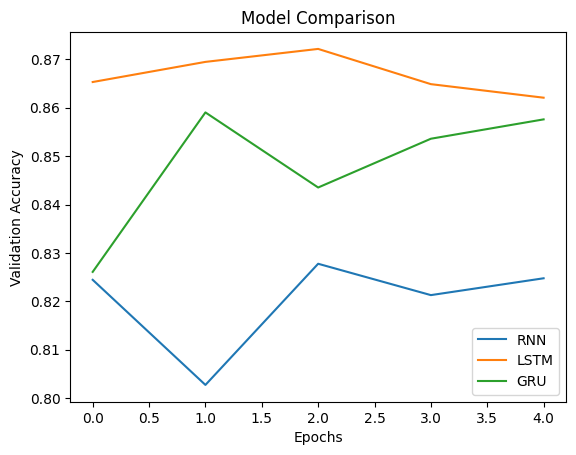

In [9]:
plt.plot(rnn_history.history['val_accuracy'], label="RNN")
plt.plot(lstm_history.history['val_accuracy'], label="LSTM")
plt.plot(gru_history.history['val_accuracy'], label="GRU")

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

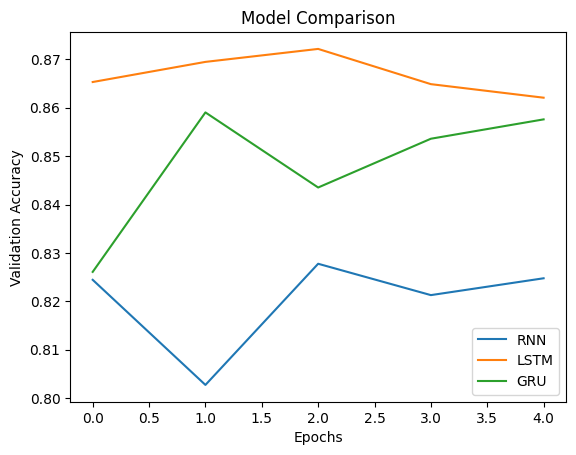

In [11]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test, y_test)
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)
gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)

print("RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8248 - loss: 0.5507
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.8621 - loss: 0.4159
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.8576 - loss: 0.3536
RNN Accuracy: 0.8247600197792053
LSTM Accuracy: 0.8620799779891968
GRU Accuracy: 0.8575999736785889
